# Controlled heterogeneity

Supporting notebook for the manuscript subsection **Controlled heterogeneity**.

It validates the final package implementation of $H$ on binary and continuous controlled models. The package computes $H$ from normalized regional sensitivity profiles. A separate raw half-$L_1$ profile-distance diagnostic is calculated only to illustrate why normalization is necessary; it is **not** the proposed heterogeneity index.

In [1]:
!pip install simdec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.1/800.1 kB 7.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import qmc
from IPython.display import display


import json
from importlib.metadata import distribution, version

import simdec as sd

assert callable(getattr(sd, "sensitivity_indices", None))
assert callable(getattr(sd, "heterogeneity_indices", None))

dist = distribution("simdec")
print("SimDec version:", version("simdec"))
print("SimDec module:", sd.__file__)

direct_url = dist.read_text("direct_url.json")
if direct_url:
    print("Installation provenance:")
    print(json.dumps(json.loads(direct_url), indent=2))
else:
    print("No direct_url.json was found for this installation.")


SEED = 42
M = 17
N = 2**M
A_VALUES = [0, 0.25, 0.5, 0.75, 1, 2, 4]
N_REGIONS = 5
pd.options.display.float_format = "{:.6f}".format

SimDec version: 1.5.2
SimDec module: /usr/local/lib/python3.13/dist-packages/simdec/__init__.py
No direct_url.json was found for this installation.


In [3]:
def raw_profile_distance(raw_profiles):
    """Mean pairwise half-L1 distance on raw regional SI profiles.

    This is a diagnostic used only for the raw-versus-normalized comparison.
    The formal H values are always taken from sd.heterogeneity_indices().
    """
    P = pd.DataFrame(raw_profiles).to_numpy(dtype=float)
    distances = []
    for r in range(len(P) - 1):
        for s in range(r + 1, len(P)):
            distances.append(0.5 * np.abs(P[r] - P[s]).sum())
    return float(np.mean(distances))


def format_interval(v):
    if isinstance(v, pd.Interval):
        return f"{v.left:.2f}–{v.right:.2f}"
    return str(v)

## Binary controlled model

In [4]:
sampler = qmc.Sobol(d=3, scramble=True, seed=SEED)
U = sampler.random_base2(M)

# X1=A, X2=K, X3=B. K is binary and therefore recognized as categorical.
X_binary = pd.DataFrame({
    "A": U[:, 0],
    "K": (U[:, 1] >= 0.5).astype(int),
    "B": U[:, 2],
})

binary_runs = {}
rows = []
for a in A_VALUES:
    y = pd.Series(X_binary["A"] + (1 + a * X_binary["K"]) * X_binary["B"], name="Y")
    H = sd.heterogeneity_indices(output=y, inputs=X_binary, n_regions=N_REGIONS)
    binary_runs[a] = H
    rows.append({
        "a": a,
        "H_K (raw S_i)": raw_profile_distance(
            H.details["K"].raw_profiles
        ),
        "H_K (normalized S_i)": H.indices["K"],
        "H_Y (raw S_i)": raw_profile_distance(
            H.details["Y"].raw_profiles
        ),
        "H_Y (normalized S_i)": H.indices["Y"],
    })

binary_results = pd.DataFrame(rows)
display(binary_results)

# Categorical self-conditioning rule and analytical population reference.
assert "K" not in binary_runs[4].details["K"].raw_profiles.columns
assert np.isclose(binary_runs[4].indices["K"], 6 / 13, atol=0.03), (
    binary_runs[4].indices["K"], 6 / 13
)

,a,H_K (raw S_i),H_K (normalized S_i),H_Y (raw S_i),H_Y (normalized S_i)
0,0.000000,0.000008,0.000003,0.097909,0.000210
1,0.250000,0.109746,0.109751,0.150499,0.065366
2,0.500000,0.192293,0.192301,0.134863,0.132165
3,0.750000,0.253827,0.253838,0.137701,0.134809
4,1.000000,0.299978,0.299991,0.117252,0.100595
5,2.000000,0.399972,0.399990,0.190527,0.169694
6,4.000000,0.461507,0.461529,0.287095,0.253495


## Figure 2

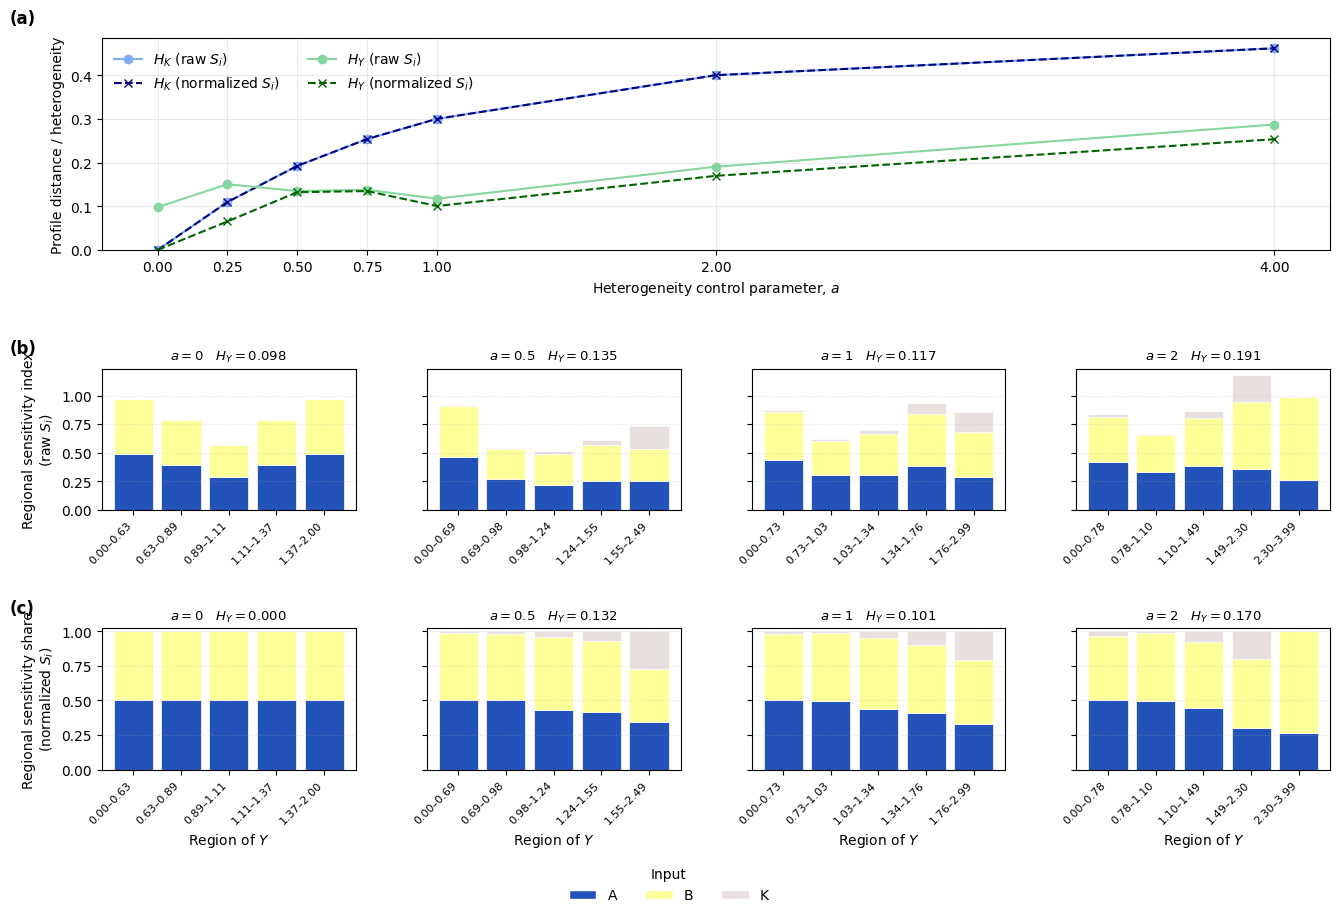

In [5]:
# Figure h1
A_PLOTS = [0, 0.5, 1, 2]

# Keep profile/legend order consistent with the manuscript figure.
PROFILE_ORDER = ["A", "B", "K"]

fig = plt.figure(figsize=(13.5, 9.2))
gs = fig.add_gridspec(
    3,
    4,
    height_ratios=[1.5, 1.0, 1.0],
    hspace=0.72,
    wspace=0.28,
)

ax_top = fig.add_subplot(gs[0, :])

ax_top.plot(
    binary_results["a"],
    binary_results["H_K (raw S_i)"],
    color="#7fb0f5",
    marker="o",
    label=r"$H_K$ (raw $S_i$)",
)

ax_top.plot(
    binary_results["a"],
    binary_results["H_K (normalized S_i)"],
    color="navy",
    marker="x",
    linestyle="--",
    label=r"$H_K$ (normalized $S_i$)",
)

ax_top.plot(
    binary_results["a"],
    binary_results["H_Y (raw S_i)"],
    color="#86d6a0",
    marker="o",
    label=r"$H_Y$ (raw $S_i$)",
)

ax_top.plot(
    binary_results["a"],
    binary_results["H_Y (normalized S_i)"],
    color="darkgreen",
    marker="x",
    linestyle="--",
    label=r"$H_Y$ (normalized $S_i$)",
)

ax_top.set_xlabel(r"Heterogeneity control parameter, $a$")
ax_top.set_ylabel("Profile distance / heterogeneity")
ax_top.set_xticks(A_VALUES)
ax_top.set_ylim(bottom=0)
ax_top.grid(alpha=0.25)
ax_top.legend(ncol=2, frameon=False, loc="upper left")

# Colors follow manuscript order: A, B, K.
cmap = plt.colormaps["terrain"]
colors = {
    name: cmap(pos)
    for name, pos in zip(
        PROFILE_ORDER,
        np.linspace(0.05, 0.95, len(PROFILE_ORDER)),
    )
}

raw_axes = []
norm_axes = []

for col, a in enumerate(A_PLOTS):
    H = binary_runs[a]

    # Explicitly reorder the stacked profiles to A -> B -> K.
    raw = H.details["Y"].raw_profiles.loc[
        :, [name for name in PROFILE_ORDER if name in H.details["Y"].raw_profiles.columns]
    ]
    norm = H.details["Y"].normalized_profiles.loc[
        :, [name for name in PROFILE_ORDER if name in H.details["Y"].normalized_profiles.columns]
    ]

    # --------------------------------------------------------
    # (b) Raw regional profiles
    # --------------------------------------------------------
    ax = fig.add_subplot(
        gs[1, col],
        sharey=raw_axes[0] if raw_axes else None,
    )
    raw_axes.append(ax)

    raw.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[colors[c] for c in raw.columns],
        edgecolor="white",
        linewidth=0.5,
        width=0.82,
        legend=False,
    )

    ax.set_title(
        rf"$a={a}$   $H_Y={raw_profile_distance(raw):.3f}$",
        fontsize=9.5,
    )
    ax.set_xlabel("")
    ax.set_xticklabels(
        [format_interval(v) for v in raw.index],
        rotation=45,
        ha="right",
        fontsize=8,
    )
    ax.grid(axis="y", linestyle=":", alpha=0.35)

    if col == 0:
        ax.set_ylabel("Regional sensitivity index\n(raw $S_i$)")
    else:
        ax.tick_params(labelleft=False)
        ax.set_ylabel("")

    # --------------------------------------------------------
    # (c) Normalized regional profiles
    # --------------------------------------------------------
    ax = fig.add_subplot(
        gs[2, col],
        sharey=norm_axes[0] if norm_axes else None,
    )
    norm_axes.append(ax)

    norm.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[colors[c] for c in norm.columns],
        edgecolor="white",
        linewidth=0.5,
        width=0.82,
        legend=False,
    )

    ax.set_title(
        rf"$a={a}$   $H_Y={H.indices['Y']:.3f}$",
        fontsize=9.5,
    )
    ax.set_xlabel("Region of $Y$")
    ax.set_xticklabels(
        [format_interval(v) for v in norm.index],
        rotation=45,
        ha="right",
        fontsize=8,
    )
    ax.set_ylim(0, 1.02)
    ax.grid(axis="y", linestyle=":", alpha=0.35)

    if col == 0:
        ax.set_ylabel("Regional sensitivity share\n(normalized $S_i$)")
    else:
        ax.tick_params(labelleft=False)
        ax.set_ylabel("")

# Shared input legend, with enough clearance from the bottom-row axis titles.
legend_handles = [
    Patch(
        facecolor=colors[name],
        edgecolor="white",
        label=name,
    )
    for name in PROFILE_ORDER
]

fig.legend(
    handles=legend_handles,
    title="Input",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.012),
    ncol=len(PROFILE_ORDER),
    frameon=False,
)

fig.subplots_adjust(
    left=0.08,
    right=0.99,
    top=0.965,
    bottom=0.17,
)

# Panel labels in figure coordinates, clear of axis labels.
fig.canvas.draw()

for label, ax in [
    ("(a)", ax_top),
    ("(b)", raw_axes[0]),
    ("(c)", norm_axes[0]),
]:
    box = ax.get_position()
    fig.text(
        0.012,
        box.y1 + 0.012,
        label,
        fontsize=12,
        fontweight="bold",
        ha="left",
        va="bottom",
    )


plt.show()

Figure 2: Controlled binary model: (a) heterogeneity indices for 𝐾 and 𝑌 , computed using both raw and normalized regional sensitivity indices; (b) 𝑌 -conditioned regional raw sensitivity profiles, revealing a decline in regional ex-plainability; and (c) 𝑌 -conditioned regional normalized sensitivity profiles, isolating changes in the relative sensitivity structure.

## Continuous controlled model

In [6]:
sampler = qmc.Sobol(d=3, scramble=True, seed=SEED + 1)
U = sampler.random_base2(M)
X_continuous = pd.DataFrame(
    {
        "A": U[:, 0],
        "B": U[:, 1],
        "C": U[:, 2],
    }
)

continuous_runs = {}
rows = []

for a in A_VALUES:
    y = pd.Series(
        X_continuous["A"]
        + (1 + a * X_continuous["C"]) * X_continuous["B"],
        name="Y",
    )

    H = sd.heterogeneity_indices(
        output=y,
        inputs=X_continuous,
        n_regions=N_REGIONS,
    )

    continuous_runs[a] = H

    rows.append(
        {
            "a": a,
            "H_C (raw S_i)": raw_profile_distance(
                H.details["C"].raw_profiles
            ),
            "H_C (normalized S_i)": H.indices["C"],
            "H_Y (raw S_i)": raw_profile_distance(
                H.details["Y"].raw_profiles
            ),
            "H_Y (normalized S_i)": H.indices["Y"],
        }
    )

continuous_results = pd.DataFrame(rows)
display(continuous_results)

,a,H_C (raw S_i),H_C (normalized S_i),H_Y (raw S_i),H_Y (normalized S_i)
0,0.000000,0.000068,0.000030,0.097843,0.000714
1,0.250000,0.043851,0.043857,0.122669,0.040326
2,0.500000,0.076567,0.076578,0.157872,0.091947
3,0.750000,0.100371,0.100386,0.179657,0.139505
4,1.000000,0.117449,0.117467,0.194440,0.177751
5,2.000000,0.147994,0.148017,0.227637,0.245868
6,4.000000,0.152352,0.152356,0.242468,0.266418


## Figure 3

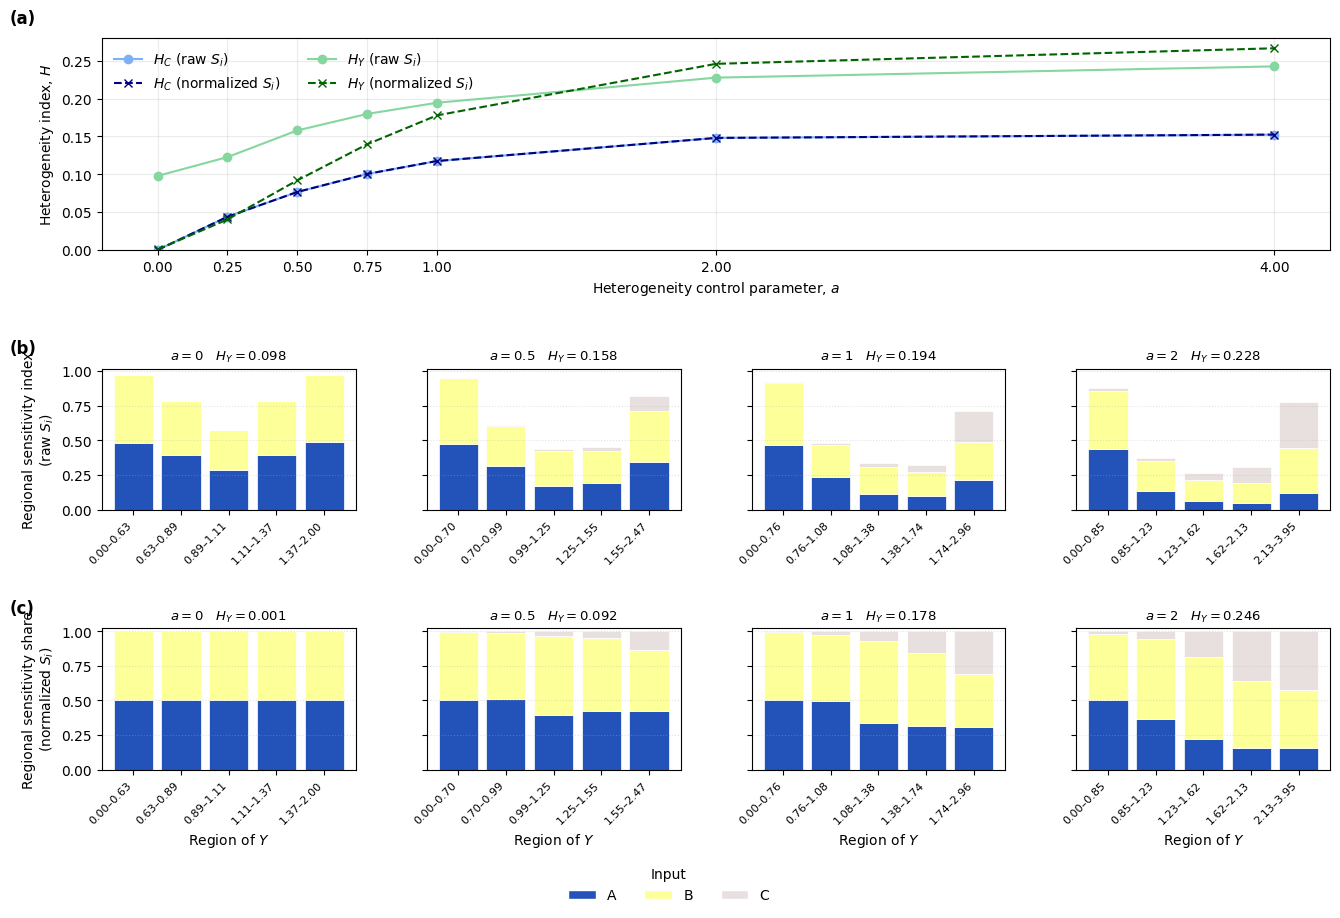

In [7]:
# Figure h2
A_PLOTS = [0, 0.5, 1, 2]

PROFILE_ORDER = ["A", "B", "C"]

fig = plt.figure(figsize=(13.5, 9.2))
gs = fig.add_gridspec(
    3,
    4,
    height_ratios=[1.5, 1.0, 1.0],
    hspace=0.72,
    wspace=0.28,
)

ax_top = fig.add_subplot(gs[0, :])

ax_top.plot(
    continuous_results["a"],
    continuous_results["H_C (raw S_i)"],
    color="#7fb0f5",
    marker="o",
    label=r"$H_C$ (raw $S_i$)",
)
ax_top.plot(
    continuous_results["a"],
    continuous_results["H_C (normalized S_i)"],
    color="navy",
    marker="x",
    linestyle="--",
    label=r"$H_C$ (normalized $S_i$)",
)
ax_top.plot(
    continuous_results["a"],
    continuous_results["H_Y (raw S_i)"],
    color="#86d6a0",
    marker="o",
    label=r"$H_Y$ (raw $S_i$)",
)
ax_top.plot(
    continuous_results["a"],
    continuous_results["H_Y (normalized S_i)"],
    color="darkgreen",
    marker="x",
    linestyle="--",
    label=r"$H_Y$ (normalized $S_i$)",
)

ax_top.set_xlabel(r"Heterogeneity control parameter, $a$")
ax_top.set_ylabel("Heterogeneity index, $H$")
ax_top.set_xticks(A_VALUES)
ax_top.set_ylim(bottom=0)
ax_top.grid(alpha=0.25)
ax_top.legend(ncol=2, frameon=False, loc="upper left")

cmap = plt.colormaps["terrain"]
colors = {
    name: cmap(pos)
    for name, pos in zip(
        PROFILE_ORDER,
        np.linspace(0.05, 0.95, len(PROFILE_ORDER)),
    )
}

raw_axes = []
norm_axes = []

for col, a in enumerate(A_PLOTS):
    H = continuous_runs[a]

    raw = H.details["Y"].raw_profiles.loc[
        :,
        [
            name
            for name in PROFILE_ORDER
            if name in H.details["Y"].raw_profiles.columns
        ],
    ]

    norm = H.details["Y"].normalized_profiles.loc[
        :,
        [
            name
            for name in PROFILE_ORDER
            if name in H.details["Y"].normalized_profiles.columns
        ],
    ]

    # Raw regional profiles
    ax = fig.add_subplot(
        gs[1, col],
        sharey=raw_axes[0] if raw_axes else None,
    )
    raw_axes.append(ax)

    raw.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[colors[c] for c in raw.columns],
        edgecolor="white",
        linewidth=0.5,
        width=0.82,
        legend=False,
    )

    ax.set_title(
        rf"$a={a}$   $H_Y={raw_profile_distance(raw):.3f}$",
        fontsize=9.5,
    )
    ax.set_xlabel("")
    ax.set_xticklabels(
        [format_interval(v) for v in raw.index],
        rotation=45,
        ha="right",
        fontsize=8,
    )
    ax.grid(axis="y", linestyle=":", alpha=0.35)

    if col == 0:
        ax.set_ylabel("Regional sensitivity index\n(raw $S_i$)")
    else:
        ax.tick_params(labelleft=False)
        ax.set_ylabel("")

    # Normalized regional profiles
    ax = fig.add_subplot(
        gs[2, col],
        sharey=norm_axes[0] if norm_axes else None,
    )
    norm_axes.append(ax)

    norm.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[colors[c] for c in norm.columns],
        edgecolor="white",
        linewidth=0.5,
        width=0.82,
        legend=False,
    )

    ax.set_title(
        rf"$a={a}$   $H_Y={H.indices['Y']:.3f}$",
        fontsize=9.5,
    )
    ax.set_xlabel("Region of $Y$")
    ax.set_xticklabels(
        [format_interval(v) for v in norm.index],
        rotation=45,
        ha="right",
        fontsize=8,
    )
    ax.set_ylim(0, 1.02)
    ax.grid(axis="y", linestyle=":", alpha=0.35)

    if col == 0:
        ax.set_ylabel("Regional sensitivity share\n(normalized $S_i$)")
    else:
        ax.tick_params(labelleft=False)
        ax.set_ylabel("")

legend_handles = [
    Patch(
        facecolor=colors[name],
        edgecolor="white",
        label=name,
    )
    for name in PROFILE_ORDER
]

fig.legend(
    handles=legend_handles,
    title="Input",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.012),
    ncol=len(PROFILE_ORDER),
    frameon=False,
)

fig.subplots_adjust(
    left=0.08,
    right=0.99,
    top=0.965,
    bottom=0.17,
)

fig.canvas.draw()

for label, ax in [
    ("(a)", ax_top),
    ("(b)", raw_axes[0]),
    ("(c)", norm_axes[0]),
]:
    box = ax.get_position()
    fig.text(
        0.012,
        box.y1 + 0.012,
        label,
        fontsize=12,
        fontweight="bold",
        ha="left",
        va="bottom",
    )

plt.show()

Figure 3: Controlled continuous model: (a) heterogeneity indices for 𝐶 and 𝑌 , computed using both raw and normalized
regional sensitivity indices; (b) 𝑌 -conditioned regional raw sensitivity profiles, showing changes in both sensitivity
composition and regional explainability; and (c) 𝑌 -conditioned regional normalized sensitivity profiles, isolating
changes in relative sensitivity structure